In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('//content/resumeJD2_pairs.csv', engine='python', on_bad_lines='skip')
print(f"Data Loaded Successfully: {df.shape[0]:,} rows, {df.shape[1]} columns")

Data Loaded Successfully: 500 rows, 4 columns


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      500 non-null    object 
 1   job_description  500 non-null    object 
 2   match_score      500 non-null    float64
 3   match_label      500 non-null    object 
dtypes: float64(1), object(3)
memory usage: 15.8+ KB


In [4]:
full_dupes = df.duplicated().sum()
print(f"Full duplicate rows: {full_dupes}")

Full duplicate rows: 0


In [5]:
# ─── Section: Uniqueness Checks ───────────────────────────────────────────────

print(f"Total rows:          {len(df)}")
print(f"Unique resumes:      {df['resume_text'].nunique()}")
print(f"Unique JDs:          {df['job_description'].nunique()}")
print(f"Unique resume+JD pairs: {df[['resume_text','job_description']].drop_duplicates().shape[0]}")

Total rows:          500
Unique resumes:      500
Unique JDs:          500
Unique resume+JD pairs: 500


In [6]:
# ─── Section: Label Consistency ───────────────────────────────────────────────

# What labels exist? (spot the case inconsistency!)
print("Unique labels found:")
print(df['match_label'].value_counts())

# Is the casing consistent?
print(f"\nExpected 3 labels, got: {df['match_label'].nunique()} unique values")
print("Distinct values:", df['match_label'].unique())

Unique labels found:
match_label
no match         190
match            158
partial match    152
Name: count, dtype: int64

Expected 3 labels, got: 3 unique values
Distinct values: ['partial match' 'no match' 'match']


In [7]:
print("Score distribution:")
print(df['match_score'].describe())
print()

# Scores must be between 0.0 and 1.0 — flag the bad ones
invalid_scores = df[(df['match_score'] < 0) | (df['match_score'] > 1)]
print(f"Invalid scores (out of 0–1 range): {len(invalid_scores)}")
print(invalid_scores[['match_label', 'match_score']])

Score distribution:
count    500.000000
mean       0.529720
std        0.283882
min        0.050000
25%        0.280000
50%        0.540000
75%        0.790000
max        0.980000
Name: match_score, dtype: float64

Invalid scores (out of 0–1 range): 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []


In [8]:
# ─── Summary: All issues found ────────────────────────────────────────────────

print("=" * 50)
print("DATA QUALITY REPORT — merged_dataset.csv")
print("=" * 50)
print(f"  Total rows:             {len(df)}")
print(f"  Full duplicates:        {df.duplicated().sum()}")
print(f"  Duplicate pairs:        {df.duplicated(subset=['resume_text','job_description']).sum()}")
print(f"  Null resume_text:       {df['resume_text'].isnull().sum()}")
print(f"  Null job_description:   {df['job_description'].isnull().sum()}")
print(f"  Label case variants:    {df['match_label'].nunique()} (expected 3)")
print(f"  Invalid scores (<0/>1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")
print("=" * 50)

DATA QUALITY REPORT — merged_dataset.csv
  Total rows:             500
  Full duplicates:        0
  Duplicate pairs:        0
  Null resume_text:       0
  Null job_description:   0
  Label case variants:    3 (expected 3)
  Invalid scores (<0/>1): 0


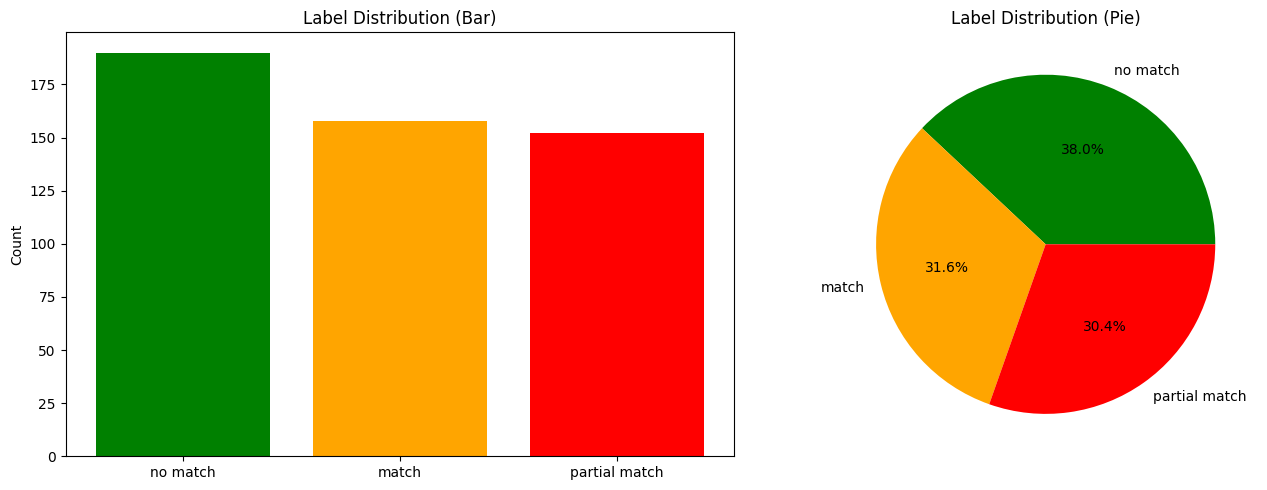

In [9]:
# Pie chart + bar side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['match_label'].str.lower().value_counts()

axes[0].bar(counts.index, counts.values, color=['green','orange','red'])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['green','orange','red'])
axes[1].set_title('Label Distribution (Pie)')

plt.tight_layout()
plt.show()

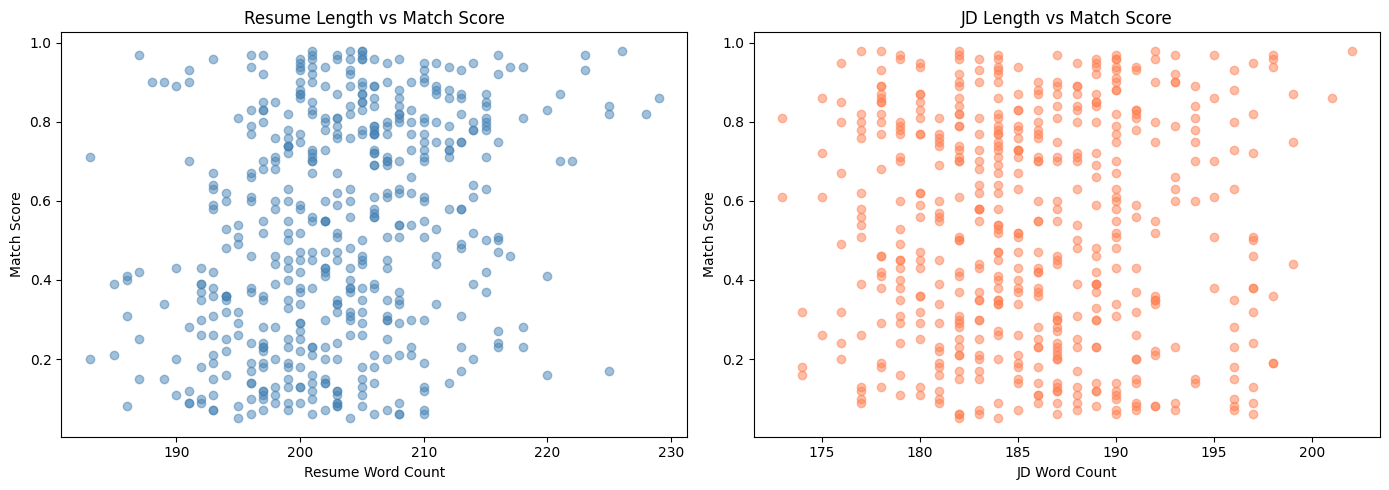

Resume length correlation: 0.286
JD length correlation:     0.001


In [10]:
df_plot=df.copy()
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len']     = df_plot['job_description'].str.split().str.len()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

plt.tight_layout()
plt.show()

# Actual correlation values
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))
print("JD length correlation:    ", df_plot['jd_len'].corr(df_plot['match_score']).round(3))

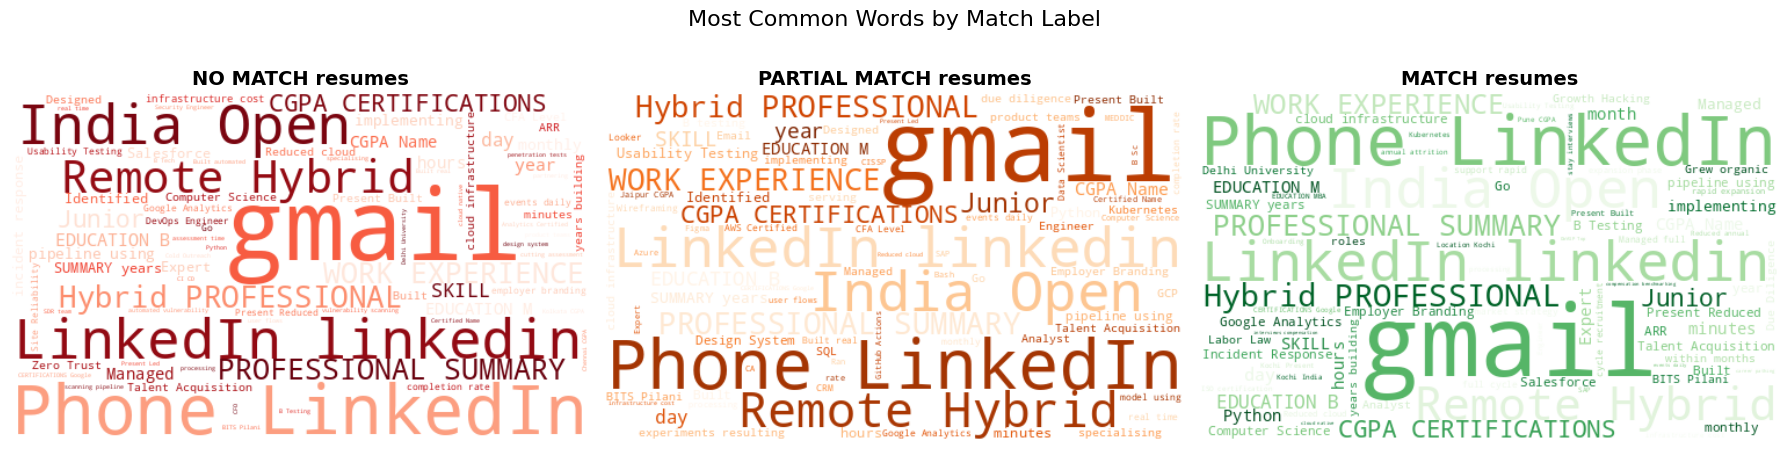

In [11]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# THE FIX: Updated labels to match the actual dataset categories
labels = ['no match', 'partial match', 'match']
colors = ['Reds', 'Oranges', 'Greens']

for ax, label, cmap in zip(axes, labels, colors):
    # 1. Get the text for the specific label
    subset = df_plot[df_plot['match_label'] == label]['resume_text'].dropna()
    text = ' '.join(subset)

    # 2. Safety Check (just in case!)
    if len(text.strip()) == 0:
        ax.axis('off')
        ax.set_title(f"No data for {label.upper()}", fontsize=14)
        continue

    # 3. Generate the word cloud
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} resumes', fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Match Label', fontsize=16)
plt.tight_layout()
plt.show()

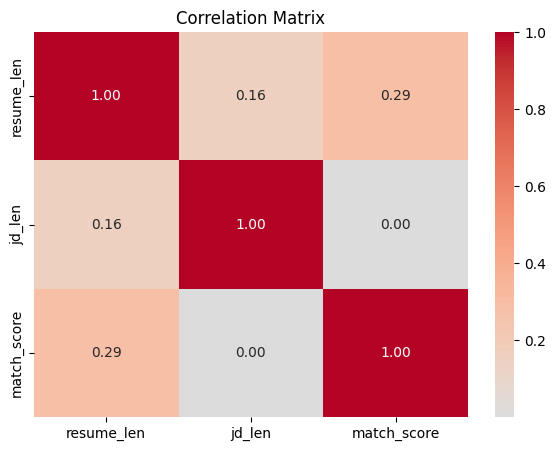

In [12]:
plt.figure(figsize=(7, 5))
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [13]:
# Change the index number [0] to look at different resumes (e.g., 1, 2, 5, etc.)
sample_index = 0

print("--- ORIGINAL UNCLEANED TEXT ---")
print(df_plot.iloc[sample_index]['resume_text'])

--- ORIGINAL UNCLEANED TEXT ---
Name: Kritika Shah || Email: kritika.shah55@gmail.com | Phone: +91-9471109191 | LinkedIn: linkedin.com/in/kritika-shah9 || Location: Ahmedabad, India | Open to: Remote / Hybrid || --- || PROFESSIONAL SUMMARY || CA/MBA with 5+ years in Valuation and Equity Research at Swiggy. Managed portfolios worth ₹4Cr. Strong track record in cost reduction and financial optimisation. || --- || SKILLS || CFA, Bloomberg Terminal, Equity Research, CA, Valuation, Growth Hacking, Product Analytics, Roadmapping || --- || WORK EXPERIENCE || FP&A Analyst | Swiggy | Ahmedabad | 2024 – Present || • Streamlined AP/AR process using Roadmapping, reducing overdue invoices by 30% and DSO by 43 days || • Managed ₹31Cr working capital portfolio, improving cash conversion cycle by 41% || • Designed Growth Hacking forecasting model with 12% accuracy, used for annual budget planning || --- || Junior FP&A Analyst | Lenskart | Ahmedabad | 2022 – 2023 || • Reduced month-end close cycle from

In [31]:
import pandas as pd

# 1. Clean Function for Resumes
def prepare_resume_for_bert(text):
    if not isinstance(text, str): return ""
    if 'PROFESSIONAL SUMMARY ||' in text:
        text = text.split('PROFESSIONAL SUMMARY ||')[-1]
    elif '|| --- ||' in text:
        text = text.split('|| --- ||')[-1]
    text = text.replace('||', '.')
    text = text.replace(' | ', ', ')
    return text.strip()

# 2. Clean Function for Job Descriptions (Slices straight to the Role & Responsibilities)
def prepare_jd_for_bert(text):
    if not isinstance(text, str): return ""
    if 'ABOUT THE ROLE ||' in text:
        text = text.split('ABOUT THE ROLE ||')[-1]
    elif '|| --- ||' in text:
        text = text.split('|| --- ||')[-1] # Fallback boundary
    text = text.replace('||', '.')
    text = text.replace(' | ', ', ')
    return text.strip()

# Apply the cleaning to both text columns
df['resume_text'] = df['resume_text'].apply(prepare_resume_for_bert)
df['job_description'] = df['job_description'].apply(prepare_jd_for_bert)

# 3. Create the lowercase label column
df['match_label_lower'] = df['match_label'].astype(str).str.lower()

# 4. Create the word count columns to get your exact 7 columns
df['resume_len'] = df['resume_text'].apply(lambda x: len(str(x).split()))
df['jd_len'] = df['job_description'].apply(lambda x: len(str(x).split()))

# Drop old tracking columns if they somehow slipped back in
columns_to_drop = ['cleaned_resume', 'clean_resume_len']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

print(f"Total Columns: {len(df.columns)}")
print(f"Columns List: {df.columns.tolist()}")

Total Columns: 7
Columns List: ['resume_text', 'job_description', 'match_score', 'match_label', 'match_label_lower', 'resume_len', 'jd_len']


In [32]:
import pandas as pd

# Force pandas to show the entire text window
with pd.option_context('display.max_colwidth', None):
    print("--- FIRST PREPPED ROW FOR BERT ---")
    print(df['resume_text'].iloc[0])

--- FIRST PREPPED ROW FOR BERT ---
CA/MBA with 5+ years in Valuation and Equity Research at Swiggy. Managed portfolios worth ₹4Cr. Strong track record in cost reduction and financial optimisation. . --- . SKILLS . CFA, Bloomberg Terminal, Equity Research, CA, Valuation, Growth Hacking, Product Analytics, Roadmapping . --- . WORK EXPERIENCE . FP&A Analyst, Swiggy, Ahmedabad, 2024 – Present . • Streamlined AP/AR process using Roadmapping, reducing overdue invoices by 30% and DSO by 43 days . • Managed ₹31Cr working capital portfolio, improving cash conversion cycle by 41% . • Designed Growth Hacking forecasting model with 12% accuracy, used for annual budget planning . --- . Junior FP&A Analyst, Lenskart, Ahmedabad, 2022 – 2023 . • Reduced month-end close cycle from 72 days to 1 days by automating CFA reconciliation in Growth Hacking . • Built Roadmapping model that identified ₹19Cr cost-saving opportunity, approved by CFO and implemented across 10 divisions . --- . EDUCATION . B.Com in 

In [33]:
df.head()

,resume_text,job_description,match_score,match_label,match_label_lower,resume_len,jd_len
0,CA/MBA with 5+ years in Valuation and Equity R...,We are looking for a passionate FP&A Analyst t...,0.55,partial match,partial match,160,145
1,Data scientist with 8 years applying B2B Sales...,We are looking for a passionate Design Lead to...,0.27,no match,no match,179,149
2,Performance marketer with 8 years scaling user...,We are looking for a passionate Security Analy...,0.46,partial match,partial match,168,140
3,SRE with 5 years ensuring 59% availability for...,We are looking for a passionate Sales Director...,0.09,no match,no match,154,155
4,Product designer with 7 years at HCL working a...,We are looking for a passionate Business Devel...,0.66,partial match,partial match,172,154


In [34]:
print(len(df.columns))

7


In [35]:
# A 15-character resume or JD is useless for training
df['resume_len'] = df['resume_text'].str.split().str.len()
df['jd_len']     = df['job_description'].str.split().str.len()

print("Short texts found:")
print(f"  resume_text < 20 words: {(df['resume_len'] < 20).sum()}")
print(f"  job_description < 10 words: {(df['jd_len'] < 10).sum()}")

# Filter out rows that are too short
df = df[(df['resume_len'] >= 20) & (df['jd_len'] >= 10)]
print(f"\nRows after removing short texts: {len(df)}")

Short texts found:
  resume_text < 20 words: 0
  job_description < 10 words: 0

Rows after removing short texts: 500


In [36]:
# Scores must be in [0.0, 1.0], anything else is a data error
invalid_mask = (df['match_score'] < 0.0) | (df['match_score'] > 1.0)
print(f"Invalid scores found: {invalid_mask.sum()}")
print(df[invalid_mask][['match_label','match_score']])

df_clean = df[~invalid_mask]
print(f"\nRows after removing invalid scores: {len(df_clean)}")

Invalid scores found: 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []

Rows after removing invalid scores: 500


In [37]:
from google.colab import files

df.to_csv('cleaned_resumeJD_pairs.csv', index=False)


files.download('cleaned_resumeJD_pairs.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>